<a href="https://colab.research.google.com/github/mohishamongia/Coin-Classification/blob/main/coinclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import numpy as np # linear algebra
import os
from time import time
from keras.preprocessing.image import ImageDataGenerator, img_to_array, image
from keras.utils import np_utils
import json
from PIL import Image
import os
import tensorflow as tf

ImportError: cannot import name 'ImageDataGenerator' from 'keras.preprocessing.image' (/usr/local/lib/python3.12/dist-packages/keras/preprocessing/image/__init__.py)

In [ ]:
#setup train, validation and test data directory
data_dir = "../input/coin-images/coins/data"

data_train_path =  data_dir + '/train'
data_valid_path = data_dir + '/validation'
data_test_path =  data_dir + '/test'

print(os.listdir("../input/coin-images/coins/data"))

['validation', 'cat_to_name.json', 'test', 'train']


In [ ]:
with open('../input/coin-images/cat_to_name.json', 'r') as json_file:
    cat_2_name = json.load(json_file)

print(cat_2_name['200'])

1 Kurus,Turkish Lira,turkey


In [ ]:
batch_size=60

# Transforms
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.1,  # randomly shift images horizontally
    height_shift_range=0.1,  # randomly shift images vertically
    horizontal_flip=True,
    featurewise_std_normalization=True,
    samplewise_std_normalization=True)

datagen_valid = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.1,  # randomly shift images horizontally
    height_shift_range=0.1,  # randomly shift images vertically
    horizontal_flip=True,
    featurewise_std_normalization=True,
    samplewise_std_normalization=True)

datagen_test = ImageDataGenerator(
    featurewise_std_normalization=True,
    samplewise_std_normalization=True,
    rescale=1./255)

/opt/conda/lib/python3.7/site-packages/keras_preprocessing/image/image_data_generator.py:349: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, which overrides setting of `featurewise_center`.
  warnings.warn('This ImageDataGenerator specifies '
/opt/conda/lib/python3.7/site-packages/keras_preprocessing/image/image_data_generator.py:356: UserWarning: This ImageDataGenerator specifies `samplewise_std_normalization`, which overrides setting of `samplewise_center`.
  warnings.warn('This ImageDataGenerator specifies '


In [ ]:
train_generator = datagen_train.flow_from_directory(
        data_train_path,
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='categorical')

valid_generator = datagen_valid.flow_from_directory(
        data_valid_path,
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='categorical')

test_generator = datagen_test.flow_from_directory(
        data_test_path,
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='categorical')

Found 6413 images belonging to 211 classes.
Found 844 images belonging to 211 classes.
Found 844 images belonging to 211 classes.


# **Visualize dataset**

/opt/conda/lib/python3.7/site-packages/keras_preprocessing/image/image_data_generator.py:720: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '
/opt/conda/lib/python3.7/site-packages/keras_preprocessing/image/image_data_generator.py:728: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '


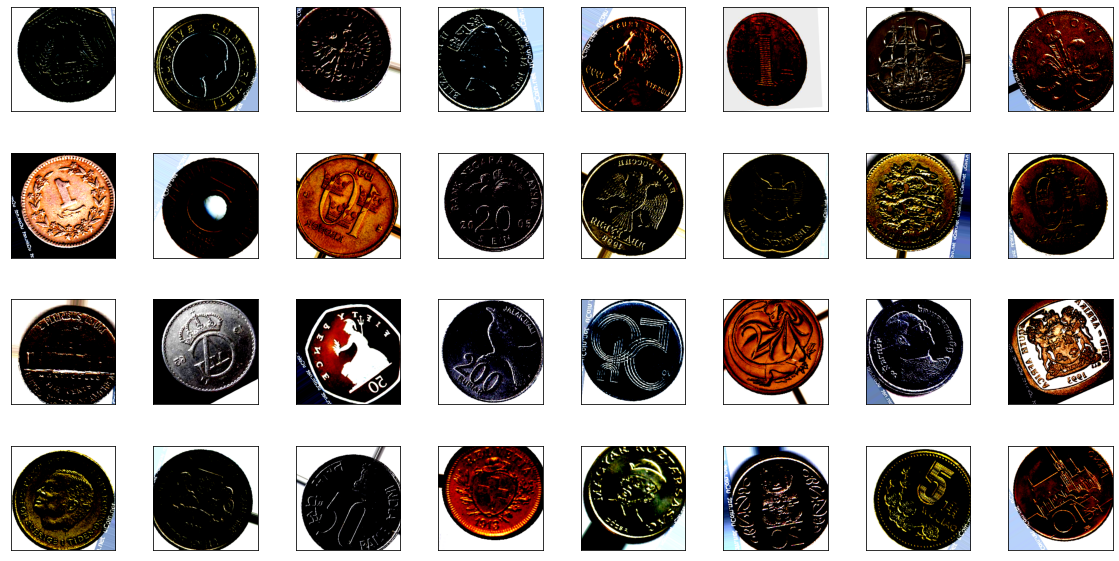

In [ ]:
import matplotlib.pyplot as plt


# Lets have a look at some of our images
images, labels = train_generator.next()

fig = plt.figure(figsize=(20,10))
fig.subplots_adjust(wspace=0.2, hspace=0.4)

# Lets show the first 32 images of a batch
for i, img in enumerate(images[:32]):
    ax = fig.add_subplot(4, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(img)
    image_idx = np.argmax(labels[i])

In [ ]:
#Keras maps each folder (class) to a number.
#Create a dictionary that maps the number assigned by keras to our folder real number
int_to_dir = {v: k for k, v in train_generator.class_indices.items()}

# **Define Inception model**

In [ ]:
from keras.applications.inception_v3 import InceptionV3
from keras.layers import Dense, Input, Dropout
from keras.models import Model
input_tensor = Input(shape=(224, 224, 3))

base_model = InceptionV3(
    include_top=False,
    weights='imagenet',
    input_tensor=input_tensor,
    input_shape=(224, 224, 3),
    pooling='max')

for layer in base_model.layers:
    layer.trainable = True  # trainable has to be false in order to freeze the layers

x = Dense(512, activation='relu')(base_model.output)
x = Dropout(.8)(x)

predictions = Dense(211, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

87924736/87910968 [==============================] - 1s 0us/step


In [ ]:
#from keras.optimizers import Adam

# compile the model (should be done *after* setting layers to non-trainable)
model.compile(optimizer = tf.keras.optimizers.Adam(lr=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


/opt/conda/lib/python3.7/site-packages/keras/optimizer_v2/optimizer_v2.py:356: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


# **Train the model**

In [ ]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

num_train = len(train_generator.filenames)
num_valid = len(valid_generator.filenames)
num_test = len(train_generator.filenames)

# When to save the model
checkpointer = ModelCheckpoint(filepath='model.weights.best.hdf5', verbose=1,
                               save_best_only=True)

# Reduce learning rate when loss doesn't improve after n epochs
scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                              patience=5, min_lr=1e-8, verbose=1)

# Stop early if model doesn't improve after n epochs
early_stopper = EarlyStopping(monitor='val_loss', patience=12,
                              verbose=0, restore_best_weights=True)

history = model.fit_generator(train_generator,
                    steps_per_epoch=num_train//batch_size,
                    epochs=100,
                    verbose=1,
                    callbacks=[checkpointer, scheduler, early_stopper],
                    validation_data=valid_generator,
                    validation_steps=num_valid//batch_size)

/opt/conda/lib/python3.7/site-packages/keras/engine/training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '
/opt/conda/lib/python3.7/site-packages/keras_preprocessing/image/image_data_generator.py:720: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '
/opt/conda/lib/python3.7/site-packages/keras_preprocessing/image/image_data_generator.py:728: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '


Epoch 1/100
106/106 [==============================] - 164s 1s/step - loss: 5.7886 - accuracy: 0.0041 - val_loss: 5.3534 - val_accuracy: 0.0060

Epoch 00001: val_loss improved from inf to 5.35343, saving model to model.weights.best.hdf5
Epoch 2/100
106/106 [==============================] - 132s 1s/step - loss: 5.3540 - accuracy: 0.0063 - val_loss: 5.3462 - val_accuracy: 0.0083

Epoch 00002: val_loss improved from 5.35343 to 5.34621, saving model to model.weights.best.hdf5
Epoch 3/100
106/106 [==============================] - 139s 1s/step - loss: 5.3487 - accuracy: 0.0076 - val_loss: 5.3363 - val_accuracy: 0.0107

Epoch 00003: val_loss improved from 5.34621 to 5.33631, saving model to model.weights.best.hdf5
Epoch 4/100
106/106 [==============================] - 132s 1s/step - loss: 5.3126 - accuracy: 0.0145 - val_loss: 5.2966 - val_accuracy: 0.0262

Epoch 00004: val_loss improved from 5.33631 to 5.29659, saving model to model.weights.best.hdf5
Epoch 5/100
106/106 [===================

Exception ignored in: <function IteratorResourceDeleter.__del__ at 0x7f6f24cc58c0>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.7/site-packages/tensorflow/python/data/ops/iterator_ops.py", line 546, in __del__
    handle=self._handle, deleter=self._deleter)
  File "/opt/conda/lib/python3.7/site-packages/tensorflow/python/ops/gen_dataset_ops.py", line 1264, in delete_iterator
    _ctx, "DeleteIterator", name, handle, deleter)
KeyboardInterrupt: 


Epoch 12/100
106/106 [==============================] - 134s 1s/step - loss: 3.4525 - accuracy: 0.3080 - val_loss: 3.1208 - val_accuracy: 0.4321

Epoch 00012: val_loss improved from 3.44317 to 3.12083, saving model to model.weights.best.hdf5
Epoch 13/100
106/106 [==============================] - 133s 1s/step - loss: 3.1234 - accuracy: 0.3635 - val_loss: 2.6931 - val_accuracy: 0.5143

Epoch 00013: val_loss improved from 3.12083 to 2.69310, saving model to model.weights.best.hdf5
Epoch 14/100
 50/106 [=============>................] - ETA: 1:01 - loss: 2.8763 - accuracy: 0.3980

KeyboardInterrupt: 

# **Save the model**

In [ ]:
model.save('inceptionv3.h5')

# **Evaluate the model**

In [ ]:
#evaluate the model on test dataset
score = model.evaluate_generator(test_generator, steps=num_test//1, verbose=1)
print('\n', 'Test accuracy:', score[1])

/opt/conda/lib/python3.7/site-packages/keras/engine/training.py:2006: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  warnings.warn('`Model.evaluate_generator` is deprecated and '


6413/6413 [==============================] - 11s 2ms/step - loss: 2.4515 - accuracy: 0.5367

 Test accuracy: 0.5367298722267151


In [ ]:
def normalizer(img):
    img_expand = np.expand_dims(img, axis=0)

    generator = ImageDataGenerator(
        featurewise_std_normalization=True,
        samplewise_std_normalization=True,
        rescale=1./255)
    image_flow = generator.flow(
        img_expand,
        y=None,
        batch_size=1
    )

    return image_flow.next()

def get_prediction(img, real_label):
    img = image.img_to_array(img)/255

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    img = (img - mean)/std

    img_expand = np.expand_dims(img, axis=0)

    prediction = model.predict(img_expand)
    prediction_int = np.argmax(prediction)

    dir_int = int_to_dir[prediction_int]
    label_name = cat_2_name[str(dir_int)]

    plt.imshow(img)

    print("Predicted: {}\nReal:      {}".format(label_name, cat_2_name[str(real_label)]))
    print()



Predicted: 2 Rupees,Pakistan Rupee,pakistan
Real:      2 Rupees,Pakistan Rupee,pakistan

Predicted: 1 Krone,Norwegian Krone,norway
Real:      100 Won,Korean Won,south_korea

Predicted: 5 Forint,Hungarian Forint,hungary
Real:      1 Cent,US Dollar,usa

Predicted: 20 Sen,Malaysian Ringgit,malaysia
Real:      10 Sen,Malaysian Ringgit,malaysia

Predicted: 1 Peso,Chilean Peso,chile
Real:      20 euro Cent,Euro,spain

Predicted: 5 Francs,Swiss Franc,switzerland
Real:      1 2 Franc,Swiss Franc,switzerland

Predicted: 5 Pence,British Pound,united_kingdom
Real:      5 Rappen,Swiss Franc,switzerland

Predicted: 1 Kurus,Turkish Lira,turkey
Real:      1 Kurus,Turkish Lira,turkey

Predicted: 50 Korun,Czech Koruna,czech_republic
Real:      50 Korun,Czech Koruna,czech_republic

Predicted: 5 Rupees,Pakistan Rupee,pakistan
Real:      5 Rupees,Pakistan Rupee,pakistan



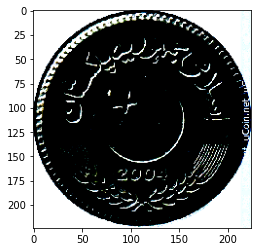

In [ ]:
for i in range(10):
    random_index = np.random.randint(0, len(test_generator.filenames))

    img = test_generator.filenames[random_index]
    img = image.load_img("../input/coin-images/coins/data/test/"+img, target_size=(224,224))
    real_label = test_generator.filenames[random_index].split("/")[0]

    get_prediction(img, real_label)